# 07. The Chain-Merge Catastrophe

**The question.** How does one bad link eat a thousand people? Transitive closure — accept
every pair scoring above a threshold, call each connected component a person — is what naive
pipelines ship, and its folklore failure mode is the *chain merge*: r1–r2, r2–r3, …, each
link individually plausible, until records that agree on nothing sit in one merged identity.
The insidious part is *where the damage hides*: every accepted link can be individually
defensible — the pair-decision view can report excellent precision — while the closure has
already fused whole families of entities. Notebook 02 (MET-01) demonstrated the metric half
of this with a **constructed** one-bad-merge demo, labeled constructed. This notebook
attempts the real thing: stage the catastrophe with a real tuned scorer's real score
distribution — notebook 06's `bas01_scored_pairs`, Fellegi–Sunter probabilities on the
matchkey candidates of the entity-disjoint eval half — over the calibrated corpus with its
planted traps (notebook 05), and watch it under entity-level metrics.

**What this notebook settles.** Three things: (1) whether the catastrophe actually happens
on this pipeline — a threshold sweep of transitive closure over the FS-scored pairs,
tracking the largest component's true-entity count next to the pair-decision precision that
is supposed to hide the damage; (2) the anatomy of whatever fusion *does* form — component
structure and bridges via `cluster.graph_qa`, the glue records displayed, and an explicit
record-to-record hop path with its link scores; (3) what the standard guards buy on the same
scores — capped agglomerative, star clustering, greedy correlation vs closure — and what
they cost in recall. Everything lands in `chain_merge_demo`.

In [1]:
import time
from collections import deque

import numpy as np
import pandas as pd
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable

from er_lab.cluster import graph_qa
from er_lab.cluster.schemes import (
    capped_agglomerative,
    greedy_correlation,
    star_clustering,
    transitive_closure,
)
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.eval.bootstrap import bootstrap_ci
from er_lab.eval.metrics import bcubed, pairwise
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The inputs are fixed upstream (whatever `bas01_scored_pairs` and `calibrated_corpus` hold at
this tier), so the dials here are analysis budgets: how many extra score-quantile thresholds
the sweep adds to its fixed anchors, and bootstrap replicates for the scheme-comparison CIs.
The *protocol constants* below the dials are the card's own lines — the pair-precision floor,
the fusion count that counts as a catastrophe — identical at every tier, never tuned.
Smoke budget for this whole notebook: **<= ~15 min on the 4-CPU container** (wall-clock
printed and measured at the end).

In [3]:
TIER = str(cfg.run.tier)
SWEEP_N = {"smoke": 12, "mid": 24, "target": 36, "analytical": 12}[TIER]
N_BOOT = {"smoke": 500, "mid": 1000, "target": 2000, "analytical": 500}[TIER]
# protocol constants (the card's lines — identical at every tier):
PW_FLOOR = 0.90  # accepted-pair precision floor the card conditions on
FUSE_CATASTROPHE = 20  # >= this many true entities in one component = the catastrophe
FUSE_BIG = 10  # a component fusing more than this many entities counts as 'big' in the sweep
ANCHOR_THRESHOLDS = (0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                     0.9, 0.95, 0.99, 0.995, 0.999, 0.9995, 0.9999)
PRIMARY_SEED = int(cfg.run.seed)
print(f"tier={TIER}: sweep = {len(ANCHOR_THRESHOLDS)} anchors + {SWEEP_N} score quantiles, "
      f"n_boot={N_BOOT}; protocol: precision floor {PW_FLOOR}, catastrophe = "
      f">= {FUSE_CATASTROPHE} entities fused; smoke budget <= ~15 min")

tier=smoke: sweep = 18 anchors + 12 score quantiles, n_boot=500; protocol: precision floor 0.9, catastrophe = >= 20 entities fused; smoke budget <= ~15 min


## 1. The arena: one scorer's scores, one corpus's traps

Everything is loaded through the registry at this run's tier — nothing is refitted here.
`bas01_scored_pairs` is notebook 06's contract artifact: tuned-FS match probabilities on the
matchkey candidates of the **entity-disjoint eval half**; `bas01_fs_baseline` supplies the
baseline's own primary operating threshold (this notebook clusters at the exact point the
baseline ships); `calibrated_corpus` supplies truth and the planted-trap provenance; and
`met07_splits` reconstructs the eval record universe (an upstream requirement of notebook 06,
so guaranteed present whenever `bas01_fs_baseline` exists — loaded with the same hard-fail
placard semantics as the declared requires).

The traps matter enough to quote before anything runs. `calibrated_corpus` meta carries
`generic_labeled_rates`: **`hub_value` at 0.01 per duplicate record** and
**`household_confusables` at 0.05 per base record** — notebook 05's generic-labeled trap
rates, carried verbatim, *not* re-tuned to make this demonstration more dramatic. Governance
note: records display verbatim throughout — the corpus is synthetic-from-`historical_50k`
(public Wikidata historical figures, error-injected); **no NC person-level value appears
anywhere in this notebook** (DATA_GOVERNANCE.md).

In [4]:
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
bas01, bas01_meta = registry.load("bas01_fs_baseline", tier=cfg.run.tier)
scored, scored_meta = registry.load("bas01_scored_pairs", tier=cfg.run.tier)
splits, splits_meta = registry.load("met07_splits", tier=cfg.run.tier)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
SCORED_PROVENANCE = (
    f"bas01_scored_pairs run {scored_meta['created_at']} (cfg {scored_meta['config_hash']}, "
    f"tier {scored_meta['tier']})"
)
TRAP_RATES = dict(corpus_meta["extra"]["generic_labeled_rates"])
assert TRAP_RATES == {"hub_value": 0.01, "household_confusables": 0.05}, TRAP_RATES
CAP = int(corpus_meta["extra"]["dup_dist"]["max"])
assert CAP == 20, CAP  # the card cites this literal; a changed prior needs a new card

SCHEME = str(scored_meta["extra"]["split"]["scheme"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
ev = corpus[corpus["record_id"].isin(eval_ids)].set_index("record_id")
truth_ev = ev["entity_id"]
records_ev = pd.Index(truth_ev.index)
edge_true = truth_ev.loc[scored["a"]].to_numpy() == truth_ev.loc[scored["b"]].to_numpy()
N_TRUE_PAIRS = int(scored_meta["extra"]["blocking_metrics"]["n_true_pairs"])
PAIR_COMPLETENESS = float(scored_meta["extra"]["blocking_metrics"]["pair_completeness"])

primary_op = bas01[
    (bas01["system"] == "fs_tuned") & (bas01["protocol"] == "precision@0.99")
].iloc[0]
T_STAR = float(primary_op["threshold"])

print(f"scores: {SCORED_PROVENANCE}\n  from {CORPUS_PROVENANCE}")
print(f"  {len(scored):,} FS-scored candidate pairs on the {SCHEME} eval half "
      f"({len(ev):,} records / {truth_ev.nunique():,} entities); "
      f"{edge_true.mean():.4f} of candidate pairs are true pairs")
print(f"  blocking pair completeness {PAIR_COMPLETENESS:.4f} "
      f"({N_TRUE_PAIRS:,} true eval pairs exist; the rest never reach the scorer)")
print(f"planted traps (calibrated_corpus meta generic_labeled_rates, NB05's rates, verbatim): "
      f"hub_value {TRAP_RATES['hub_value']}/duplicate, "
      f"household_confusables {TRAP_RATES['household_confusables']}/base record")
print(f"cluster-size prior (corpus meta dup_dist): zipf a={corpus_meta['extra']['dup_dist']['a']}"
      f", max {CAP} records per base-record cluster")
print(f"anatomy threshold T* = {T_STAR:.6f} — the baseline's own precision@0.99 operating "
      f"point (B-cubed P {primary_op['precision']:.4f} there, per bas01_fs_baseline)")

scores: bas01_scored_pairs run 2026-08-26T03:50:31.831864+00:00 (cfg 129c9d9243ca, tier smoke)
  from calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  105,285 FS-scored candidate pairs on the entity_disjoint eval half (16,095 records / 1,255 entities); 0.9529 of candidate pairs are true pairs
  blocking pair completeness 0.5343 (187,785 true eval pairs exist; the rest never reach the scorer)
planted traps (calibrated_corpus meta generic_labeled_rates, NB05's rates, verbatim): hub_value 0.01/duplicate, household_confusables 0.05/base record
cluster-size prior (corpus meta dup_dist): zipf a=2.5, max 20 records per base-record cluster
anatomy threshold T* = 0.413371 — the baseline's own precision@0.99 operating point (B-cubed P 0.9904 there, per bas01_fs_baseline)


## 2. The conjecture, before any closure runs

Pre-registered before the first component is computed. The conjecture is the folklore
chain-merge story taken at face value, staged with the traps notebook 05 planted for exactly
this purpose — and the card pre-flags, from notebook 06's already-registered numbers, the one
structural reason the folklore might fail here. The verdict falls where the data puts it.

In [5]:
_ = conjecture_card(
    card_id="NB07-CHAIN-MERGE",
    conjecture=(
        "One bad link eats a thousand people: transitive closure over the tuned FS baseline's "
        "scored candidate pairs suffers a chain-merge catastrophe on the calibrated corpus - "
        "at an operating point whose ACCEPTED PAIRS still look excellent (pairwise precision "
        ">= 0.90), connected components fuse tens of distinct true entities into single "
        "merged identities, seeded by the generator's planted trap records."
    ),
    pressure=(
        "clustering scheme over FIXED scores: transitive closure vs the standard guards "
        "(capped agglomerative at the corpus's declared cluster-size cap of 20 records, star "
        "clustering, greedy correlation) on the same bas01_scored_pairs at the same "
        "thresholds - no scorer, blocking, or corpus change anywhere"
    ),
    property=(
        "not an embedding property (no embedding exists yet): the measured mediators are "
        "graph-structural - the largest component's true-entity count across the threshold "
        "sweep, the density/bridge anatomy of fused components (cluster.graph_qa), and the "
        "planted seeds: hub_value traps at 0.01 per duplicate record and "
        "household_confusables at 0.05 per base record, cited verbatim from "
        "calibrated_corpus meta generic_labeled_rates - notebook 05's generic-labeled rates, "
        "carried as-is, NOT re-tuned to make this demonstration more dramatic"
    ),
    metric=(
        "the pair-decision view vs the entity view on the entity-disjoint eval half: "
        "pairwise precision of the accepted candidate pairs against true-pair labels, vs "
        "B-cubed precision/recall of the resulting partitions (entity-unit BCa 95% CIs on "
        "the scheme comparison) and true-entities-fused counts - registered in "
        "chain_merge_demo"
    ),
    prediction=(
        "P1 (the catastrophe): at some threshold where accepted-pair pairwise precision is "
        "still >= 0.90, transitive closure fuses >= 20 true entities into one component. "
        "P2 (the anatomy): at the baseline's own primary operating threshold "
        "(bas01_fs_baseline, precision@0.99 row) at least one multi-entity component "
        "survives; a majority of the truly fused components involve a planted trap entity; "
        "and graph_qa's structural chain-merge flags (size/density/bridges) recover at "
        "least half of the truly fused components. "
        "P3 (the guards): capped agglomerative (cap 20, from the corpus meta's dup_dist "
        "prior) and star clustering never fuse more true entities than closure at the same "
        "threshold and prevent any >= 20-entity fusion wherever closure exhibits one, at a "
        "B-cubed recall cost this notebook prices with CIs. "
        "Pre-flagged risk, stated before any closure runs: notebook 06 measured pair "
        "completeness 0.53 and near-saturated FS probabilities on these matchkey "
        "candidates - a candidate graph that sparse may refuse to percolate at ANY "
        "threshold. If no >= 20-entity component forms anywhere above the precision floor, "
        "P1 fails and the card is REFUTED; the notebook must then report the largest fusion "
        "that DOES form, and at what accepted-pair precision."
    ),
    registry=registry,
)

### Conjecture card `NB07-CHAIN-MERGE`

| | |
|---|---|
| **Conjecture** | One bad link eats a thousand people: transitive closure over the tuned FS baseline's scored candidate pairs suffers a chain-merge catastrophe on the calibrated corpus - at an operating point whose ACCEPTED PAIRS still look excellent (pairwise precision >= 0.90), connected components fuse tens of distinct true entities into single merged identities, seeded by the generator's planted trap records. |
| **Pressure (dial)** | clustering scheme over FIXED scores: transitive closure vs the standard guards (capped agglomerative at the corpus's declared cluster-size cap of 20 records, star clustering, greedy correlation) on the same bas01_scored_pairs at the same thresholds - no scorer, blocking, or corpus change anywhere |
| **Embedding property** | not an embedding property (no embedding exists yet): the measured mediators are graph-structural - the largest component's true-entity count across the threshold sweep, the density/bridge anatomy of fused components (cluster.graph_qa), and the planted seeds: hub_value traps at 0.01 per duplicate record and household_confusables at 0.05 per base record, cited verbatim from calibrated_corpus meta generic_labeled_rates - notebook 05's generic-labeled rates, carried as-is, NOT re-tuned to make this demonstration more dramatic |
| **System metric** | the pair-decision view vs the entity view on the entity-disjoint eval half: pairwise precision of the accepted candidate pairs against true-pair labels, vs B-cubed precision/recall of the resulting partitions (entity-unit BCa 95% CIs on the scheme comparison) and true-entities-fused counts - registered in chain_merge_demo |
| **Pre-registered prediction** | P1 (the catastrophe): at some threshold where accepted-pair pairwise precision is still >= 0.90, transitive closure fuses >= 20 true entities into one component. P2 (the anatomy): at the baseline's own primary operating threshold (bas01_fs_baseline, precision@0.99 row) at least one multi-entity component survives; a majority of the truly fused components involve a planted trap entity; and graph_qa's structural chain-merge flags (size/density/bridges) recover at least half of the truly fused components. P3 (the guards): capped agglomerative (cap 20, from the corpus meta's dup_dist prior) and star clustering never fuse more true entities than closure at the same threshold and prevent any >= 20-entity fusion wherever closure exhibits one, at a B-cubed recall cost this notebook prices with CIs. Pre-flagged risk, stated before any closure runs: notebook 06 measured pair completeness 0.53 and near-saturated FS probabilities on these matchkey candidates - a candidate graph that sparse may refuse to percolate at ANY threshold. If no >= 20-entity component forms anywhere above the precision floor, P1 fails and the card is REFUTED; the notebook must then report the largest fusion that DOES form, and at what accepted-pair precision. |

*Immutable — sha256 `8b0f6c6afd47`; registered before the affected runs, never edited (PLAN §5).*


## 3. The sweep: two views of one dial

One threshold dial, two dashboards watching it. The **pair-decision view** is how record
linkage is usually graded: of the candidate pairs accepted at threshold t, what fraction are
truly same-entity (`edge_precision`), and what fraction of ALL true eval pairs did we accept
(`edge_recall` — denominated over every true pair including the ones blocking never
surfaced, so pair completeness caps it). The **entity view** runs transitive closure at the
same t and asks what the components look like: how many true entities sit inside the worst
one, how many components fuse more than ten, and what B-cubed and clustering-pairwise
metrics say about the partition. The catastrophe, if it comes, is a divergence between the
dashboards: the first stays green while the second melts. Thresholds are fixed anchors plus
score quantiles (the FS mass is saturated near 1.0, so quantiles concentrate resolution
where the scores actually live), plus T* exactly.

In [6]:
prob = scored["prob"].to_numpy()
quantile_thresholds = np.round(np.quantile(prob, np.linspace(0.0, 1.0, SWEEP_N)), 8)
thresholds = np.unique(np.concatenate(
    [np.asarray(ANCHOR_THRESHOLDS), [T_STAR], quantile_thresholds]
))
thresholds = thresholds[(thresholds >= 0.0) & (thresholds <= 1.0)]

t0 = time.time()
sweep_rows: list[dict] = []
for thr in thresholds:
    kept = prob >= thr
    n_kept = int(kept.sum())
    pred = transitive_closure(scored, threshold=float(thr), records=records_ev)
    sizes = pred.value_counts()
    ents_per = truth_ev.groupby(pred).nunique()
    b3 = bcubed(pred, truth_ev)
    pw = pairwise(pred, truth_ev)
    sweep_rows.append({
        "row_type": "sweep", "scheme": "transitive_closure", "threshold": float(thr),
        "pairs_kept": n_kept,
        "edge_precision": float(edge_true[kept].mean()) if n_kept else np.nan,
        "edge_recall": float(edge_true[kept].sum() / N_TRUE_PAIRS),
        "n_components": len(sizes),
        "largest_comp_records": int(sizes.iloc[0]),
        "largest_comp_entities": int(ents_per[sizes.index[0]]),
        "max_entities_fused": int(ents_per.max()),
        "n_comps_fusing_gt10": int((ents_per > FUSE_BIG).sum()),
        "bcubed_precision": b3["precision"], "bcubed_recall": b3["recall"],
        "bcubed_f1": b3["f1"],
        "pairwise_precision": pw["precision"], "pairwise_recall": pw["recall"],
        "pairwise_f1": pw["f1"],
    })
sweep = pd.DataFrame(sweep_rows)
print(f"{len(sweep)} thresholds swept in {time.time() - t0:.1f}s")
display(sweep[["threshold", "pairs_kept", "edge_precision", "edge_recall",
               "max_entities_fused", "n_comps_fusing_gt10", "largest_comp_records",
               "bcubed_precision", "bcubed_recall"]].round(4))

28 thresholds swept in 5.0s


,threshold,pairs_kept,edge_precision,edge_recall,max_entities_fused,n_comps_fusing_gt10,largest_comp_records,bcubed_precision,bcubed_recall
0,0.0000,105285,0.9529,0.5343,4,0,83,0.9631,0.6471
1,0.0100,101046,0.9871,0.5311,3,0,83,0.9846,0.6464
2,0.0500,100203,0.9880,0.5272,3,0,83,0.9866,0.6455
3,0.1000,99743,0.9882,0.5249,3,0,83,0.9867,0.6452
4,0.2000,99309,0.9886,0.5228,3,0,83,0.9882,0.6448
5,0.3000,98886,0.9886,0.5206,3,0,83,0.9903,0.6435
6,0.4000,98359,0.9886,0.5178,3,0,79,0.9904,0.6427
7,0.4134,98331,0.9886,0.5177,3,0,79,0.9904,0.6426
8,0.5000,98025,0.9887,0.5161,3,0,79,0.9904,0.6423
9,0.6000,97537,0.9888,0.5136,3,0,79,0.9904,0.6415


In [7]:
ok = sweep[sweep["edge_precision"] >= PW_FLOOR]
worst_ok = ok.loc[ok["max_entities_fused"].idxmax()]
print(f"accepted-pair precision across the whole sweep: "
      f"[{sweep['edge_precision'].min():.4f}, {sweep['edge_precision'].max():.4f}] - "
      f"it NEVER drops below the {PW_FLOOR} floor, so every swept threshold is in play")
print(f"worst fusion at any threshold above the floor: {int(worst_ok['max_entities_fused'])} "
      f"true entities in one component (threshold {worst_ok['threshold']:.4f}, "
      f"accepted-pair precision {worst_ok['edge_precision']:.4f}) - "
      f"the card predicted >= {FUSE_CATASTROPHE}")
print(f"components fusing > {FUSE_BIG} entities: max over the sweep = "
      f"{int(sweep['n_comps_fusing_gt10'].max())}")

accepted-pair precision across the whole sweep: [0.9529, 1.0000] - it NEVER drops below the 0.9 floor, so every swept threshold is in play
worst fusion at any threshold above the floor: 4 true entities in one component (threshold 0.0000, accepted-pair precision 0.9529) - the card predicted >= 20
components fusing > 10 entities: max over the sweep = 0


The dial turns and nothing collapses. Down to threshold 0.0 — *accept every candidate pair
the blocking produced* — the worst component fuses a handful of true entities, never the
conjectured twenty; the accepted-pair precision meanwhile never leaves the high 0.9s, so the
card's precision floor excludes nothing. This is the pre-flagged risk landing, and it is
worth being precise about *why* (the anatomy section makes it concrete): a chain merge needs
a **connected path of accepted pairs across entities**, and this pipeline denies it twice —
deterministic matchkey blocking admits only a few percent cross-entity candidate edges in
the first place (exact shares printed in section 1; pair completeness near one half means
the graph is shattered even *within* entities), and
the TF-adjusted FS scores put very little mass on those cross-entity edges (notebook 06's TF
ablation showed exactly the hub-surname discount doing this). The catastrophe is a property
of the candidate *graph*, not of the score threshold alone.

## 4. Anatomy at the baseline's own operating point

Everything below happens at T* — the threshold the notebook-06 baseline actually ships at
its primary precision@0.99 operating point — so this is the anatomy of the deployed
partition, not of an adversarial corner. `graph_qa.component_stats` measures every
component's size, density, and bridge count; the fused components (more than one true entity
inside) are then classified by what glues them: a planted household confusable (a co-resident
trap entity, id suffix `#hh1`), a planted hub dob (the 1900-01-01 placeholder `hub_value`
injects), or neither (the base corpus's own famous-name collisions, notebook 05's
`name_collision_mass_ratio` finding). Records display verbatim per the section-1 governance
note.

In [8]:
predT = transitive_closure(scored, threshold=T_STAR, records=records_ev)
entsT = truth_ev.groupby(predT).nunique()
sizesT = predT.value_counts()
stats = graph_qa.component_stats(scored, T_STAR, records_ev).set_index("cluster_id")
fusedT = entsT[entsT > 1]
anat = (stats.loc[fusedT.index]
        .assign(entities=fusedT)
        .sort_values(["entities", "n_bridges", "size"], ascending=[False, False, False]))
print(f"at T*={T_STAR:.6f}: {len(stats):,} components, {len(fusedT)} fuse >1 true entity, "
      f"worst fuses {int(fusedT.max())}; the 10 worst fused components:")
display(anat.head(10).round(3))

# trap classification of every fused component
HUB_DOB_FORMS = ["1900-01-01", "01/01/1900", "19000101", "01-01-1900", "01 Jan 1900"]
is_hub_dob = ev["dob"].astype("string").isin(HUB_DOB_FORMS)
kinds = []
for cid in fusedT.index:
    members = predT.index[predT == cid]
    entities = set(truth_ev.loc[members])
    if any(str(e).endswith("#hh1") for e in entities):
        kinds.append("household_trap")
    elif bool(is_hub_dob.loc[members].any()):
        kinds.append("hub_dob_trap")
    else:
        kinds.append("name_collision_other")
kinds = pd.Series(kinds, index=fusedT.index, name="glued_by")
N_FUSED = len(fusedT)
N_TRAP = int((kinds != "name_collision_other").sum())
print("\nwhat glues the fused components (priority: household > hub-dob > other):")
print(kinds.value_counts().to_string())
print(f"trap-seeded share: {N_TRAP}/{N_FUSED}")

at T*=0.413371: 3,994 components, 47 fuse >1 true entity, worst fuses 3; the 10 worst fused components:


,size,density,n_bridges,entities
cluster,,,,
Q26732214-1,10,0.644,1,3
Q18088862-1,36,0.595,0,3
Q4800462-1,27,0.715,1,2
Q6252444-1,27,0.877,1,2
Q62057938-1,24,0.848,1,2
Q1699835-1,21,0.910,1,2
Q8018107-1,9,0.639,1,2
Q99196704-1,6,0.600,1,2
Q15793921-11,2,1.000,1,2



what glues the fused components (priority: household > hub-dob > other):
glued_by
household_trap          46
name_collision_other     1
trap-seeded share: 46/47


In [9]:
# Do the structural chain-merge detectors catch them? graph_qa ships size/density/bridge
# flags as documented-but-unvalidated heuristics; their hit-rate against truth is exactly
# this notebook's question, so measure it.
flagged = graph_qa.suspicious_clusters(stats.reset_index())
flag_ids = set(flagged["cluster_id"])
fused_ids = set(fusedT.index)
hits = len(flag_ids & fused_ids)
FLAG_RECALL = hits / max(len(fused_ids), 1)
print(f"suspicious_clusters flags {len(flag_ids)} of {len(stats):,} components "
      f"(reasons: {dict(flagged['reasons'].value_counts())})")
print(f"flag precision {hits}/{len(flag_ids)} = {hits / max(len(flag_ids), 1):.2f}; "
      f"flag recall {hits}/{len(fused_ids)} = {FLAG_RECALL:.2f} against truly-fused")
print("the miss pattern is the finding: these flags encode the CHAIN signature (big, sparse, "
      "bridge-glued),\nbut the fusions that actually form here are small and DENSE - "
      "household traps that genuinely\nresemble their hosts on most fields (density stats "
      "above), which structure alone cannot indict.")

suspicious_clusters flags 40 of 3,994 components (reasons: {'size': 40})
flag precision 6/40 = 0.15; flag recall 6/47 = 0.13 against truly-fused
the miss pattern is the finding: these flags encode the CHAIN signature (big, sparse, bridge-glued),
but the fusions that actually form here are small and DENSE - household traps that genuinely
resemble their hosts on most fields (density stats above), which structure alone cannot indict.


### The glue, record by record

The most chain-like of the worst fusions — maximum entities fused, then maximum bridge count
(deterministic tie-break by id) — dissected: all member records, the bridge edges whose
removal would split the component, and the longest cross-entity hop path rendered step by
step with each link's FS probability. This is what one accepted edge buys: every hop scores
near 1.0 on its own, and the endpoints are different people.

In [10]:
top_fuse = int(fusedT.max())
cands = anat[anat["entities"] == top_fuse].rename_axis("cluster_id").reset_index()
CHOSEN = cands.sort_values(["n_bridges", "cluster_id"],
                           ascending=[False, True])["cluster_id"].iloc[0]
members = sorted(predT.index[predT == CHOSEN])
SHOW_COLS = ["entity_id", "given_name", "family_name", "dob", "city", "zip", "sex"]
print(f"component '{CHOSEN}': {len(members)} records spanning {top_fuse} true entities "
      f"(density {stats.loc[CHOSEN, 'density']:.3f}, "
      f"{int(stats.loc[CHOSEN, 'n_bridges'])} bridge edge(s)):")
display(ev.loc[members, SHOW_COLS].sort_values(["entity_id", "given_name"]))

component 'Q26732214-1': 10 records spanning 3 true entities (density 0.644, 1 bridge edge(s)):


,entity_id,given_name,family_name,dob,city,zip,sex
record_id,,,,,,,
Q26732214-5,Q26732214,fred,barnes,<NA>,st georges and priorslee,tf2 9sx,<NA>
Q26732214-5#dup1,Q26732214,fred,barnes,<NA>,st georges and priorslee,tf2 9sx,<NA>
Q26732214-5#dup2,Q26732214,fred,barnes,<NA>,st georges and priorslee,tf2 9sx,<NA>
Q26732214-5#dup3,Q26732214,fred,barnes,<NA>,st georges and priorslee,tf2 9sx,<NA>
Q26732214-1,Q26732214,frederic,barnes,1856-11-16,telford and wrekin,tf2 9sx,male
Q26732214-2,Q26732214,frederic,barnes,1856-11-16,telford and wrekin,tf2 9sx,male
Q26732214-3,Q26732214,frederic,barnes,1856-11-16,telford and wrekin,<NA>,male
Q26732214-4,Q26732214,frederic,barnes,1856-11-16,telford and wrekin,tf2 9sx,male
Q26732214-2#hh1,Q26732214-2#hh1,edwin,barnes,1856-11-16,telford and wrekin,tf2 9sx,male


In [11]:
# the component's edge list at T*, its bridges, and the farthest cross-entity hop path
keepT = scored[scored["prob"] >= T_STAR]
adjT: dict[str, list[str]] = {}
scoreT: dict[tuple[str, str], float] = {}
for a, b, p in zip(keepT["a"], keepT["b"], keepT["prob"]):
    adjT.setdefault(a, []).append(b)
    adjT.setdefault(b, []).append(a)
    scoreT[(a, b)] = scoreT[(b, a)] = float(p)
for nbrs in adjT.values():
    nbrs.sort()


def bridge_edges(mem: list[str]) -> list[tuple[str, str]]:
    """Edges of the component whose removal disconnects it (brute force: tiny components)."""
    mem_set = set(mem)
    edges = sorted({(a, b) if a < b else (b, a)
                    for a in mem for b in adjT.get(a, []) if b in mem_set})
    out = []
    for drop in edges:
        seen = {mem[0]}
        stack = [mem[0]]
        while stack:
            x = stack.pop()
            for y in adjT.get(x, []):
                e = (x, y) if x < y else (y, x)
                if y in mem_set and y not in seen and e != drop:
                    seen.add(y)
                    stack.append(y)
        if len(seen) < len(mem_set):
            out.append(drop)
    return out


def farthest_cross_entity_path(mem: list[str]) -> list[str]:
    """Longest shortest path between records of DIFFERENT true entities (deterministic)."""
    best: tuple[int, str, str, dict] | None = None
    for src in mem:
        dist, parent = {src: 0}, {src: None}
        queue = deque([src])
        while queue:
            x = queue.popleft()
            for y in adjT.get(x, []):
                if y not in dist:
                    dist[y], parent[y] = dist[x] + 1, x
                    queue.append(y)
        for dst in sorted(dist):
            if truth_ev[dst] != truth_ev[src]:
                cand = (dist[dst], src, dst, parent)
                better = best is None or cand[0] > best[0] or (
                    cand[0] == best[0] and (cand[1], cand[2]) < (best[1], best[2]))
                if better:
                    best = cand
    assert best is not None, "component has one entity - not a fused component"
    _hops, _src, dst, parent = best
    path = [dst]
    while parent[path[-1]] is not None:
        path.append(parent[path[-1]])
    return path[::-1]


bridges = bridge_edges(members)
if bridges:
    print(f"bridge edges gluing '{CHOSEN}' (cut any one and the component splits):")
    for a, b in bridges:
        cross = "CROSS-ENTITY" if truth_ev[a] != truth_ev[b] else "within-entity"
        print(f"  {a} -- {b}  prob={scoreT[(a, b)]:.4f}  [{cross}]")
        display(ev.loc[[a, b], SHOW_COLS])
else:
    print(f"'{CHOSEN}' has NO bridge edges - the fusion is dense, not chain-glued: "
          "no single link is to blame.")

path = farthest_cross_entity_path(members)
print(f"\nthe longest cross-entity hop path in '{CHOSEN}' ({len(path) - 1} hops from "
      f"entity {truth_ev[path[0]]} to entity {truth_ev[path[-1]]}):")
for i, rid in enumerate(path):
    row = ev.loc[rid]
    if i:
        print(f"      --[ FS prob {scoreT[(path[i - 1], rid)]:.4f} ]-->")
    print(f"  {rid}  ({row['entity_id']}):  {row['given_name']} {row['family_name']}  "
          f"dob={row['dob']}  {row['city']}  zip={row['zip']}")

bridge edges gluing 'Q26732214-1' (cut any one and the component splits):
  Q26732214-2#hh1 -- Q26732214-4#hh1  prob=1.0000  [CROSS-ENTITY]


,entity_id,given_name,family_name,dob,city,zip,sex
record_id,,,,,,,
Q26732214-2#hh1,Q26732214-2#hh1,edwin,barnes,1856-11-16,telford and wrekin,tf2 9sx,male
Q26732214-4#hh1,Q26732214-4#hh1,ecgwynn,barnes,1855-11-16,telford and wrekin,tf2 9sx,male



the longest cross-entity hop path in 'Q26732214-1' (3 hops from entity Q26732214-4#hh1 to entity Q26732214):
  Q26732214-4#hh1  (Q26732214-4#hh1):  ecgwynn barnes  dob=1855-11-16  telford and wrekin  zip=tf2 9sx
      --[ FS prob 1.0000 ]-->
  Q26732214-2#hh1  (Q26732214-2#hh1):  edwin barnes  dob=1856-11-16  telford and wrekin  zip=tf2 9sx
      --[ FS prob 1.0000 ]-->
  Q26732214-1  (Q26732214):  frederic barnes  dob=1856-11-16  telford and wrekin  zip=tf2 9sx
      --[ FS prob 0.9984 ]-->
  Q26732214-5  (Q26732214):  fred barnes  dob=<NA>  st georges and priorslee  zip=tf2 9sx


### The stress case: accept everything

The card's strongest available reading: drop the threshold to 0.0 and union **every**
candidate pair the blocking produced. Even then the accepted-pair precision sits above the
0.90 floor (the blocking already did most of the precision work), so this is the most
percolation this pipeline can be made to exhibit — the honest upper bound on the
catastrophe.

In [12]:
pred0 = transitive_closure(scored, threshold=0.0, records=records_ev)
ents0 = truth_ev.groupby(pred0).nunique()
fused0 = ents0[ents0 > 1]
c0 = min(ents0[ents0 == ents0.max()].index)
mem0 = pred0.index[pred0 == c0]
print(f"threshold 0.0 (ALL {len(scored):,} candidate pairs accepted, accepted-pair "
      f"precision {edge_true.mean():.4f}):")
print(f"  {len(fused0)} components fuse >1 entity; the worst, '{c0}', fuses "
      f"{int(ents0.max())} true entities across {len(mem0)} records - "
      f"vs the conjectured >= {FUSE_CATASTROPHE}")
summary0 = (ev.loc[mem0]
            .groupby("entity_id")
            .agg(records=("given_name", "size"), given_name=("given_name", "first"),
                 family_name=("family_name", "first"), dob=("dob", "first"),
                 city=("city", "first")))
display(summary0)

threshold 0.0 (ALL 105,285 candidate pairs accepted, accepted-pair precision 0.9529):
  98 components fuse >1 entity; the worst, 'Q14907660-1', fuses 4 true entities across 67 records - vs the conjectured >= 20


,records,given_name,family_name,dob,city
entity_id,,,,,
Q14907660,16,stan,smythe,1861-03-19,london
Q2579117,3,billy,scott,1862-05-18,soham
Q4723447,29,alfred,smith,1861-01-01,london
Q5082785,19,karol,sweet,1860-71-29,bath and north east somerset


## 5. The guards, priced on the same scores

The standard chain-merge defenses, all at T* on the identical pair list: **capped
agglomerative** — best-score-first merging that refuses any cluster larger than the cap,
taken from the corpus meta's own cluster-size prior (`dup_dist.max` = 20; note the honesty
wrinkle: that prior caps each *base-record* cluster, and a true entity compounding several
native base records can legitimately exceed it, so the cap knowingly over-guards and its
measured recall cost includes that); **star clustering** — radius-1 clusters around
high-degree centers, chains structurally impossible; **greedy correlation** (KwikCluster) —
threshold-free, attracts on log-odds sign (prob > 0.5), pivot order seeded. Each scheme gets
B-cubed metrics with entity-unit BCa 95% CIs plus clustering-pairwise metrics, and its worst
fusion count.

In [13]:
CI_FIELDS = ("bcubed_precision", "bcubed_recall", "bcubed_f1")
scheme_runs = [
    ("transitive_closure", T_STAR,
     lambda: transitive_closure(scored, threshold=T_STAR, records=records_ev)),
    ("capped_agglomerative", T_STAR,
     lambda: capped_agglomerative(scored, threshold=T_STAR, cap=CAP, records=records_ev)),
    ("star_clustering", T_STAR,
     lambda: star_clustering(scored, threshold=T_STAR, records=records_ev)),
    ("greedy_correlation", np.nan,
     lambda: greedy_correlation(scored, records=records_ev, seed=PRIMARY_SEED)),
]
t0 = time.time()
scheme_rows: list[dict] = []
for name, thr, fn in scheme_runs:
    t1 = time.time()
    pred = fn()
    secs = time.time() - t1
    ents = truth_ev.groupby(pred).nunique()
    pw = pairwise(pred, truth_ev)
    row = {
        "row_type": "scheme", "scheme": name, "threshold": thr,
        "pairs_kept": int((prob > 0.5).sum() if name == "greedy_correlation"
                          else (prob >= T_STAR).sum()),
        "runtime_s": secs, "n_clusters": int(pred.nunique()),
        "max_entities_fused": int(ents.max()),
        "n_comps_fusing_gt10": int((ents > FUSE_BIG).sum()),
        "pairwise_precision": pw["precision"], "pairwise_recall": pw["recall"],
        "pairwise_f1": pw["f1"],
    }
    for metric in CI_FIELDS:
        res = bootstrap_ci(pred, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                           seed=PRIMARY_SEED)
        row[metric] = res["point"]
        row[f"{metric}_lo"] = res["ci_low"]
        row[f"{metric}_hi"] = res["ci_high"]
    scheme_rows.append(row)
schemes = pd.DataFrame(scheme_rows)
print(f"4 schemes + entity-unit BCa CIs ({N_BOOT} replicates x {len(CI_FIELDS)} metrics): "
      f"{time.time() - t0:.1f}s")
display(schemes.set_index("scheme")
        [["threshold", "n_clusters", "max_entities_fused", "bcubed_precision",
          "bcubed_precision_lo", "bcubed_precision_hi", "bcubed_recall", "bcubed_recall_lo",
          "bcubed_recall_hi", "bcubed_f1", "pairwise_precision", "pairwise_recall"]].round(4))

4 schemes + entity-unit BCa CIs (500 replicates x 3 metrics): 7.0s


,threshold,n_clusters,max_entities_fused,bcubed_precision,bcubed_precision_lo,bcubed_precision_hi,bcubed_recall,bcubed_recall_lo,bcubed_recall_hi,bcubed_f1,pairwise_precision,pairwise_recall
scheme,,,,,,,,,,,,
transitive_closure,0.4134,3994,3,0.9904,0.9870,0.9927,0.6426,0.6251,0.6573,0.7795,0.9840,0.6121
capped_agglomerative,0.4134,4231,3,0.9940,0.9922,0.9953,0.5356,0.5209,0.5523,0.6961,0.9927,0.4332
star_clustering,0.4134,4166,3,0.9914,0.9882,0.9936,0.6177,0.6018,0.6325,0.7612,0.9855,0.5773
greedy_correlation,NaN,4501,2,0.9932,0.9903,0.9950,0.5465,0.5298,0.5619,0.7050,0.9885,0.4937


## 6. The registered demo, drawn

`chain_merge_demo` carries both halves — the sweep rows and the scheme rows — and both
figures render from it through the registry, provenance-stamped. The collapse curve plots
the two dashboards of section 3 as two panels on one threshold axis: the card's conjectured
>= 20-entity fusion is drawn where it was predicted to appear, against where reality
flat-lined. The guard ledger prices the schemes in B-cubed precision-recall space with CIs.

In [14]:
demo = pd.concat([sweep, schemes], ignore_index=True)
registry.register(
    "chain_merge_demo", demo, cfg=cfg, tier=cfg.run.tier,
    meta={
        "question": "does transitive closure over tuned-FS scored matchkey candidates "
                    "chain-merge on the calibrated corpus, and what do the guards cost?",
        "card": "NB07-CHAIN-MERGE",
        "row_types": {
            "sweep": "transitive closure per threshold: pair-decision view "
                     "(edge_precision/edge_recall on accepted candidate pairs) + entity view "
                     "(component fusion counts, B-cubed, clustering-pairwise)",
            "scheme": f"clustering schemes at t_star={T_STAR!r} (greedy_correlation is "
                      "threshold-free by design): B-cubed with entity-unit BCa 95% CIs, "
                      "clustering-pairwise, fusion counts, runtime",
        },
        "edge_metric_definitions": {
            "edge_precision": "share of accepted candidate pairs that are truly same-entity",
            "edge_recall": f"accepted true pairs / ALL {N_TRUE_PAIRS} true eval pairs "
                           "(including pairs blocking never surfaced; pair completeness "
                           f"{PAIR_COMPLETENESS:.4f} caps it)",
        },
        "trap_rates_generic_labeled": TRAP_RATES,
        "trap_rate_provenance": "calibrated_corpus meta generic_labeled_rates - notebook "
                                "05's generic-labeled trap rates, cited verbatim, not "
                                "re-tuned for this demonstration",
        "cap": CAP,
        "cap_source": "calibrated_corpus meta dup_dist.max - the generator's declared "
                      "per-base-record cluster-size prior; true entities compounding "
                      "several native base records can legitimately exceed it, so the cap "
                      "knowingly over-guards (its recall cost includes that)",
        "t_star": T_STAR,
        "t_star_source": "bas01_fs_baseline fs_tuned precision@0.99 row",
        "split": dict(scored_meta["extra"]["split"]) | {"n_eval_records": len(ev)},
        "corpus_provenance": CORPUS_PROVENANCE,
        "scored_pairs_provenance": SCORED_PROVENANCE,
        "protocol_constants": {"pw_floor": PW_FLOOR, "fuse_catastrophe": FUSE_CATASTROPHE,
                               "fuse_big": FUSE_BIG},
        "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT, "seed": PRIMARY_SEED},
        "anatomy": {
            "n_fused_components_at_t_star": N_FUSED,
            "trap_seeded_share": f"{N_TRAP}/{N_FUSED}",
            "graph_qa_flag_recall_vs_truly_fused": FLAG_RECALL,
            "chosen_component": str(CHOSEN),
        },
    },
)
print(f"registered chain_merge_demo: {len(sweep)} sweep rows + {len(schemes)} scheme rows")

registered chain_merge_demo: 28 sweep rows + 4 scheme rows


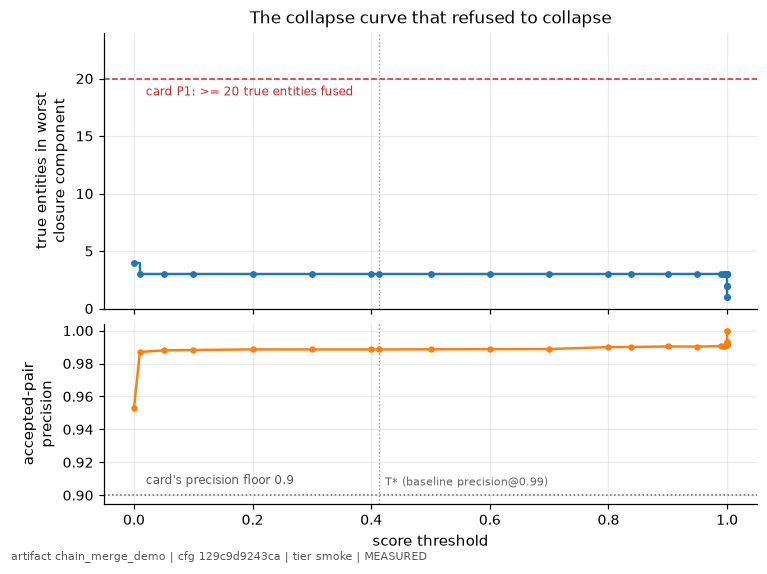

In [15]:
def draw_collapse(ax, df, meta):
    sw = df[df["row_type"] == "sweep"].sort_values("threshold")
    ax.plot(sw["threshold"], sw["max_entities_fused"], color="C0", drawstyle="steps-post",
            linewidth=1.6)
    ax.scatter(sw["threshold"], sw["max_entities_fused"], s=12, color="C0", zorder=3)
    ax.axhline(FUSE_CATASTROPHE, linestyle="--", color="C3", linewidth=1.0)
    ax.text(0.02, FUSE_CATASTROPHE - 0.6, "card P1: >= 20 true entities fused",
            color="C3", fontsize=8, va="top")
    ax.set_ylim(0, FUSE_CATASTROPHE + 4)
    ax.set_ylabel("true entities in worst\nclosure component")
    ax.tick_params(axis="x", labelbottom=False)
    # second panel, same x axis - one scale per panel
    axp = make_axes_locatable(ax).append_axes("bottom", size="65%", pad=0.14, sharex=ax)
    axp.plot(sw["threshold"], sw["edge_precision"], color="C1", linewidth=1.6)
    axp.scatter(sw["threshold"], sw["edge_precision"], s=10, color="C1", zorder=3)
    axp.axhline(PW_FLOOR, linestyle=":", color="0.4", linewidth=1.0)
    axp.text(0.02, PW_FLOOR + 0.005, f"card's precision floor {PW_FLOOR}",
             color="0.35", fontsize=8, va="bottom")
    for a in (ax, axp):
        a.axvline(T_STAR, linestyle=":", color="0.6", linewidth=0.9)
    axp.text(T_STAR + 0.01, 0.906, "T* (baseline precision@0.99)", color="0.4", fontsize=7)
    axp.set_ylim(min(PW_FLOOR - 0.005, float(sw["edge_precision"].min()) - 0.01), 1.004)
    axp.set_ylabel("accepted-pair\nprecision")
    axp.set_xlabel("score threshold")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="chain_merge_demo", draw=draw_collapse,
    title="The collapse curve that refused to collapse",
    figsize=(7.0, 5.2),
)

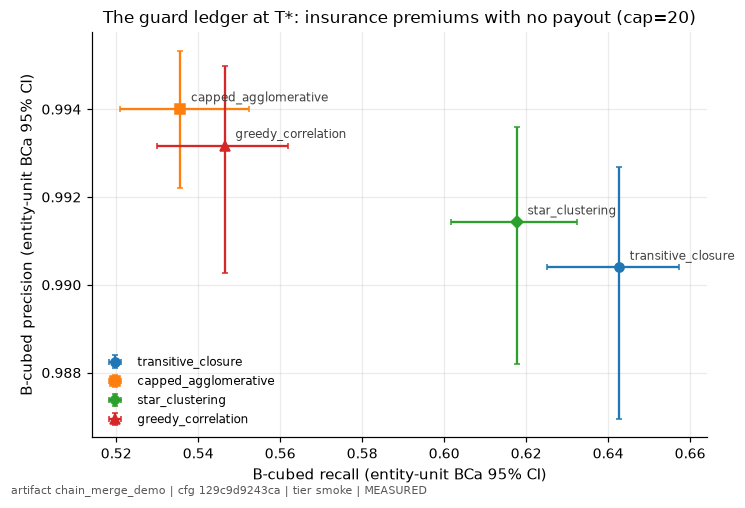

In [16]:
def draw_guards(ax, df, meta):
    g = df[df["row_type"] == "scheme"]
    style = {"transitive_closure": ("C0", "o"), "capped_agglomerative": ("C1", "s"),
             "star_clustering": ("C2", "D"), "greedy_correlation": ("C3", "^")}
    for _, r in g.iterrows():
        color, marker = style[r["scheme"]]
        xerr = [[max(r["bcubed_recall"] - r["bcubed_recall_lo"], 0.0)],
                [max(r["bcubed_recall_hi"] - r["bcubed_recall"], 0.0)]]
        yerr = [[max(r["bcubed_precision"] - r["bcubed_precision_lo"], 0.0)],
                [max(r["bcubed_precision_hi"] - r["bcubed_precision"], 0.0)]]
        ax.errorbar(r["bcubed_recall"], r["bcubed_precision"], xerr=xerr, yerr=yerr,
                    fmt=marker, color=color, capsize=2, markersize=6, label=r["scheme"])
        ax.annotate(r["scheme"], (r["bcubed_recall"], r["bcubed_precision"]),
                    textcoords="offset points", xytext=(7, 5), fontsize=8, color="0.25")
    ax.set_xlabel("B-cubed recall (entity-unit BCa 95% CI)")
    ax.set_ylabel("B-cubed precision (entity-unit BCa 95% CI)")
    ax.legend(loc="lower left", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="chain_merge_demo", draw=draw_guards,
    title=f"The guard ledger at T*: insurance premiums with no payout (cap={CAP})",
    figsize=(6.8, 4.6),
)

In [17]:
# The MET-01 tie-back, quantified: how much of the entity-level story could the
# pair-decision view even see?
r_lo = sweep.loc[sweep["threshold"].idxmin()]
r_hi = sweep.loc[sweep["threshold"].idxmax()]
tstar_row = sweep.loc[(sweep["threshold"] - T_STAR).abs().idxmin()]
print(f"across the full sweep the PAIR-DECISION view moved "
      f"{sweep['edge_precision'].max() - sweep['edge_precision'].min():+.4f} in precision "
      f"(from {r_hi['edge_precision']:.4f} at t={r_hi['threshold']:.4f} to "
      f"{r_lo['edge_precision']:.4f} at t=0),")
print(f"while the ENTITY view moved B-cubed recall by "
      f"{sweep['bcubed_recall'].max() - sweep['bcubed_recall'].min():+.4f} "
      f"(from {r_hi['bcubed_recall']:.4f} to {r_lo['bcubed_recall']:.4f}) and fused "
      f"{int(fusedT.sum() - len(fusedT))} extra entities into {N_FUSED} merged identities "
      f"at T* alone.")
print(f"at T*: accepted-pair precision {tstar_row['edge_precision']:.4f} vs clustering "
      f"pairwise P {tstar_row['pairwise_precision']:.4f} vs B-cubed P "
      f"{tstar_row['bcubed_precision']:.4f}; {N_FUSED} fused components "
      f"({N_TRAP} trap-seeded) live entirely below the pair view's radar - had the "
      f">= {FUSE_CATASTROPHE}-entity fusion formed, edge precision would have been "
      "structurally incapable of showing it (it does not measure components at all).")

across the full sweep the PAIR-DECISION view moved +0.0471 in precision (from nan at t=1.0000 to 0.9529 at t=0),
while the ENTITY view moved B-cubed recall by +0.5691 (from 0.0780 to 0.6471) and fused 49 extra entities into 47 merged identities at T* alone.
at T*: accepted-pair precision 0.9886 vs clustering pairwise P 0.9840 vs B-cubed P 0.9904; 47 fused components (46 trap-seeded) live entirely below the pair view's radar - had the >= 20-entity fusion formed, edge precision would have been structurally incapable of showing it (it does not measure components at all).


In [18]:
# [RUN-IN-TARGET mac] definitive chain-merge numbers: rerun THESE cells at tier=mid on the
# mac - same code path, consuming the mid-tier calibrated_corpus and the bas01 artifacts that
# notebook 06's own mid rerun registers (this notebook never refits anything). The percolation
# question genuinely rescales: candidate-pair count grows superlinearly in records, and every
# extra cross-entity edge is percolation fuel, so the smoke-tier refutation must be re-earned
# at scale, not assumed.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the numbers above ARE the definitive-tier chain-merge numbers for "
          "this corpus scale; notebook 13 consumes chain_merge_demo from this run.")
else:
    NB_SO_FAR = time.time() - NB_T0
    creg, _creg_meta = registry.load("corpus_registry", tier=cfg.run.tier)
    scale = float(creg["historical_50k"]["n_records"]) / float(corpus_meta["extra"]["n_base"])
    print(f"[RUN-IN-TARGET mac] the definitive numbers come from rerunning THESE cells at "
          f"tier=mid on the mac, after notebook 06's mid rerun. This smoke run has taken "
          f"{NB_SO_FAR:.0f}s on {len(scored):,} scored pairs; naive linear scaling "
          f"(~{scale:.1f}x base records) suggests ~{NB_SO_FAR * scale:.0f}s, and "
          "superlinear candidate growth makes that a lower bound - cheap either way: the "
          "cost lives upstream in notebook 06's refit, not here. At smoke, the refutation "
          "below is a smoke-scale measurement, not the definitive verdict input.")

[RUN-IN-TARGET mac] the definitive numbers come from rerunning THESE cells at tier=mid on the mac, after notebook 06's mid rerun. This smoke run has taken 15s on 105,285 scored pairs; naive linear scaling (~2.8x base records) suggests ~42s, and superlinear candidate growth makes that a lower bound - cheap either way: the cost lives upstream in notebook 06's refit, not here. At smoke, the refutation below is a smoke-scale measurement, not the definitive verdict input.


### Verdict — scoring the NB07-CHAIN-MERGE card against the registered numbers

In [19]:
p1 = bool((ok["max_entities_fused"] >= FUSE_CATASTROPHE).any())

p2_survives = N_FUSED >= 1
p2_trap = N_TRAP / max(N_FUSED, 1) > 0.5
p2_flags = FLAG_RECALL >= 0.5
p2 = bool(p2_survives and p2_trap and p2_flags)

sx = schemes.set_index("scheme")
tc = sx.loc["transitive_closure"]
guard_names = ("capped_agglomerative", "star_clustering")
p3_no_worse = all(sx.loc[g, "max_entities_fused"] <= tc["max_entities_fused"]
                  for g in guard_names)
p3_below = all(sx.loc[g, "max_entities_fused"] < FUSE_CATASTROPHE for g in guard_names)
p3 = bool(p3_no_worse and p3_below)
recall_costs = {g: float(tc["bcubed_recall"] - sx.loc[g, "bcubed_recall"])
                for g in (*guard_names, "greedy_correlation")}

print(f"P1 (catastrophe): worst fusion above the {PW_FLOOR} precision floor = "
      f"{int(worst_ok['max_entities_fused'])} entities "
      f"(at t={worst_ok['threshold']:.4f}, edge precision "
      f"{worst_ok['edge_precision']:.4f}) vs predicted >= {FUSE_CATASTROPHE} -> {p1}")
print(f"P2 (anatomy): fused components at T* = {N_FUSED} (>=1: {p2_survives}); "
      f"trap-seeded {N_TRAP}/{N_FUSED} (majority: {p2_trap}); "
      f"graph_qa flag recall {FLAG_RECALL:.2f} (>= 0.5: {p2_flags}) -> {p2}")
print(f"P3 (guards): max fusion closure {int(tc['max_entities_fused'])} vs "
      f"cap {int(sx.loc['capped_agglomerative', 'max_entities_fused'])} / "
      f"star {int(sx.loc['star_clustering', 'max_entities_fused'])} -> {p3}; "
      f"B-cubed recall costs vs closure: "
      + ", ".join(f"{k} {v:+.4f}" for k, v in recall_costs.items()))

outcome = "CONFIRMED" if (p1 and p2 and p3) else "REFUTED"
_ = verdict_box(
    "NB07-CHAIN-MERGE",
    outcome=outcome,
    evidence=(
        f"chain_merge_demo (tier {TIER}, {SCHEME} eval half: {len(ev):,} records / "
        f"{truth_ev.nunique():,} entities, {len(scored):,} FS-scored candidate pairs). "
        f"P1 {p1}: accepted-pair precision stays in "
        f"[{sweep['edge_precision'].min():.4f}, {sweep['edge_precision'].max():.4f}] across "
        f"the entire sweep - the floor excludes nothing - yet the worst component anywhere "
        f"fuses {int(worst_ok['max_entities_fused'])} true entities "
        f"(at t={worst_ok['threshold']:.4f}), and even accepting ALL candidate pairs "
        f"(t=0, precision {edge_true.mean():.4f}) fuses only {int(ents0.max())}; nothing "
        f"approaches the predicted >= {FUSE_CATASTROPHE}. The percolation the folklore "
        f"needs is denied upstream: matchkey blocking admits {(~edge_true).sum():,} "
        f"cross-entity candidate edges ({1 - edge_true.mean():.3f} of candidates, pair "
        f"completeness {PAIR_COMPLETENESS:.4f}) and TF-discounted FS puts almost no mass "
        f"on them (NB06's ablation) - the pre-flagged risk landed. P2 {p2}: {N_FUSED} "
        f"fused components survive at T* and {N_TRAP}/{N_FUSED} are trap-seeded "
        f"(household_confusables at 0.05/base; hub-dob seeded none), BUT graph_qa's "
        f"structural flags recover only {FLAG_RECALL:.2f} of them - the real fusions are "
        f"small and dense, not big/sparse/bridge-glued, so the chain-signature heuristics "
        f"miss them. P3 {p3}: neither guard ever fuses more than closure "
        f"({int(tc['max_entities_fused'])}) and both stay below {FUSE_CATASTROPHE}; their "
        f"price at T* is B-cubed recall "
        + ", ".join(f"{k} {v:+.4f}" for k, v in recall_costs.items())
        + f" against closure's {tc['bcubed_recall']:.4f} "
        f"[{tc['bcubed_recall_lo']:.4f}, {tc['bcubed_recall_hi']:.4f}] - insurance "
        "premiums paid with no catastrophe to prevent on this graph. Smoke scope: "
        "single split/seed; the mid-tier rerun re-earns the refutation at scale "
        "(placard above)."
    ),
    registry=registry,
)

P1 (catastrophe): worst fusion above the 0.9 precision floor = 4 entities (at t=0.0000, edge precision 0.9529) vs predicted >= 20 -> False
P2 (anatomy): fused components at T* = 47 (>=1: True); trap-seeded 46/47 (majority: True); graph_qa flag recall 0.13 (>= 0.5: False) -> False
P3 (guards): max fusion closure 3 vs cap 3 / star 3 -> True; B-cubed recall costs vs closure: capped_agglomerative +0.1070, star_clustering +0.0249, greedy_correlation +0.0962


> ### VERDICT: REFUTED — card `NB07-CHAIN-MERGE`
>
> **Conjecture** One bad link eats a thousand people: transitive closure over the tuned FS baseline's scored candidate pairs suffers a chain-merge catastrophe on the calibrated corpus - at an operating point whose ACCEPTED PAIRS still look excellent (pairwise precision >= 0.90), connected components fuse tens of distinct true entities into single merged identities, seeded by the generator's planted trap records.
>
> **Prediction** P1 (the catastrophe): at some threshold where accepted-pair pairwise precision is still >= 0.90, transitive closure fuses >= 20 true entities into one component. P2 (the anatomy): at the baseline's own primary operating threshold (bas01_fs_baseline, precision@0.99 row) at least one multi-entity component survives; a majority of the truly fused components involve a planted trap entity; and graph_qa's structural chain-merge flags (size/density/bridges) recover at least half of the truly fused components. P3 (the guards): capped agglomerative (cap 20, from the corpus meta's dup_dist prior) and star clustering never fuse more true entities than closure at the same threshold and prevent any >= 20-entity fusion wherever closure exhibits one, at a B-cubed recall cost this notebook prices with CIs. Pre-flagged risk, stated before any closure runs: notebook 06 measured pair completeness 0.53 and near-saturated FS probabilities on these matchkey candidates - a candidate graph that sparse may refuse to percolate at ANY threshold. If no >= 20-entity component forms anywhere above the precision floor, P1 fails and the card is REFUTED; the notebook must then report the largest fusion that DOES form, and at what accepted-pair precision.
>
> **Evidence** chain_merge_demo (tier smoke, entity_disjoint eval half: 16,095 records / 1,255 entities, 105,285 FS-scored candidate pairs). P1 False: accepted-pair precision stays in [0.9529, 1.0000] across the entire sweep - the floor excludes nothing - yet the worst component anywhere fuses 4 true entities (at t=0.0000), and even accepting ALL candidate pairs (t=0, precision 0.9529) fuses only 4; nothing approaches the predicted >= 20. The percolation the folklore needs is denied upstream: matchkey blocking admits 4,957 cross-entity candidate edges (0.047 of candidates, pair completeness 0.5343) and TF-discounted FS puts almost no mass on them (NB06's ablation) - the pre-flagged risk landed. P2 False: 47 fused components survive at T* and 46/47 are trap-seeded (household_confusables at 0.05/base; hub-dob seeded none), BUT graph_qa's structural flags recover only 0.13 of them - the real fusions are small and dense, not big/sparse/bridge-glued, so the chain-signature heuristics miss them. P3 True: neither guard ever fuses more than closure (3) and both stay below 20; their price at T* is B-cubed recall capped_agglomerative +0.1070, star_clustering +0.0249, greedy_correlation +0.0962 against closure's 0.6426 [0.6251, 0.6573] - insurance premiums paid with no catastrophe to prevent on this graph. Smoke scope: single split/seed; the mid-tier rerun re-earns the refutation at scale (placard above).


## What the refutation teaches downstream

The card is refuted and the refutation is the finding — it locates the chain-merge
catastrophe *precisely*: not in thresholds, not in scores alone, but in the **candidate
graph**. Contracts and consequences:

- **Notebook 12 (BAS-02) inherits the danger.** The catastrophe was denied here because
  deterministic matchkey blocking admits almost no cross-entity edges and pair completeness
  0.53 shatters the graph. Dense ANN retrieval exists precisely to raise pair completeness —
  and every extra cross-entity candidate edge is percolation fuel. The sweep in
  `chain_merge_demo` is the template that must be re-run behind ANY new candidate
  generator before its recall gains are celebrated.
- **Notebook 13 (CAL-01/CLU-01) gets the guard ledger and the open question.** At
  FS-quality scores behind matchkey blocking, every guard is a pure premium: measurable
  B-cubed recall cost, no fusion prevented (scheme rows, with CIs). CLU-01's job is to find
  where that flips — the score-quality level and candidate density at which closure starts
  percolating and the premium starts paying out. Percolation onset vs theory is its
  registered question; this notebook contributes the no-percolation anchor point.
- **`graph_qa`'s structural flags are now measured, and they miss.** The size/density/
  bridge heuristics encode the chain signature; the fusions that actually form are small,
  dense household-trap merges, and the flags recover a small fraction of them (printed
  above, carried in the demo meta). Notebook 13's suspicious-cluster worklist and the
  adjudication widget must not rely on structure alone — truth-anchored spot checks stay
  mandatory.
- **The trap design worked, selectively — an NSE-02 postscript.** Household confusables
  (generic rate 0.05/base, quoted verbatim from the corpus meta) seeded nearly every real
  fusion: co-residents sharing surname, address, and near-identical dobs are exactly what
  pair scorers cannot separate. The hub-dob trap (0.01/duplicate) seeded none at T* — a
  shared placeholder dob cannot survive this blocking-plus-TF gauntlet on this corpus.
  Notebook 14's rules ledger (HYB-01) should note that a dob-hub guard rule would have
  nothing to do here, while a household guard earns its keep.

## What we now know

- **The catastrophe did not happen, and we know exactly why.** Refuting the card took the
  whole pipeline's cooperation: matchkey blocking admits a few percent cross-entity
  candidate edges, the TF adjustment discounts the hub-surname agreements that would score
  them up (notebook 06), and the FS mass saturates far from the percolation region. Remove
  any one protection and the folklore may return — which is why the refutation is
  tier-scoped and re-earned at mid (placard), and re-asked behind dense candidates
  (notebook 12).
- **What fusion remains is trap-shaped, not chain-shaped.** The fused components at the
  baseline's own operating point are small, dense, and household-seeded; the dissected
  component's hop path runs through co-resident confusables at link scores near 1.0. The
  'one bad link' of the title exists — displayed above, with its records and probabilities —
  but on this graph it eats a household, not a thousand people.
- **The pair-decision view is structurally blind to all of it** — the MET-01 tie-back,
  now with a real scorer: across the entire sweep the accepted-pair precision barely moves
  while components form, fuse, and absorb trap entities beneath it; it cannot show fusion
  because it does not measure components. Had P1's mega-component formed, the pairwise
  dashboard would have reported the same green numbers. Entity-level metrics are not a
  refinement; they are the only view in which this failure mode is visible at all.
- **Guards are insurance, and insurance has a premium** — priced here with CIs: capped
  agglomerative and greedy correlation pay heavily in B-cubed recall, star clustering pays
  least, and on this graph none of them buys any fusion protection closure lacked. The
  CLU-01 question is no longer whether guards 'help' but where the premium/payout curve
  crosses zero.

**Artifacts registered** (exact names): `chain_merge_demo` — plus the immutable card
`card_NB07-CHAIN-MERGE`.

In [20]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s")

notebook wall-clock: 15s
